In [26]:
import numpy as np
import pandas as pd

In [27]:
df = pd.read_csv("/home/junix/sms-spam-classifier/spam.csv", encoding="latin-1")
print(df)

        v1                                                 v2 Unnamed: 2  \
0      ham  Go until jurong point, crazy.. Available only ...        NaN   
1      ham                      Ok lar... Joking wif u oni...        NaN   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3      ham  U dun say so early hor... U c already then say...        NaN   
4      ham  Nah I don't think he goes to usf, he lives aro...        NaN   
...    ...                                                ...        ...   
5567  spam  This is the 2nd time we have tried 2 contact u...        NaN   
5568   ham              Will Ì_ b going to esplanade fr home?        NaN   
5569   ham  Pity, * was in mood for that. So...any other s...        NaN   
5570   ham  The guy did some bitching but I acted like i'd...        NaN   
5571   ham                         Rofl. Its true to its name        NaN   

     Unnamed: 3 Unnamed: 4  
0           NaN        NaN  
1           NaN        NaN  


In [28]:
df.shape

(5572, 5)

In [29]:
# 1. cleeaning the data
# 2. EDA
# 3. Text Preprocessing
# 4. Model Building
# 5. Model Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [31]:
df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], inplace=True)

In [32]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [33]:
df.rename(columns={"v1": "target", "v2": "text"}, inplace=True)
df.sample(8)

,target,text
4912,spam,"Goal! Arsenal 4 (Henry, 7 v Liverpool 2 Henry ..."
2478,ham,Not yet. Just i'd like to keep in touch and it...
4723,spam,FREE GAME. Get Rayman Golf 4 FREE from the O2 ...
1824,ham,Sent me ur email id soon
2080,ham,Where is it. Is there any opening for mca.
2882,ham,Anything lor is she coming?
3206,ham,This phone has the weirdest auto correct.
4226,ham,Buy one egg for me da..please:)


In [34]:
# df["target"] = df["target"].map({"ham": "0", "spam": "1"})
# df.sample(10)

In [35]:
# df["target"] = (df["target"] == "ham").astype(int)
# df.head()

In [36]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["target"] = encoder.fit_transform(df["target"])
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [37]:

#checking for missing and duplicate values
print(df.isnull().sum())


target    0
text      0
dtype: int64


In [38]:
print(df.duplicated().sum())

403


In [39]:
df = df.drop_duplicates(keep="first")
print(df.duplicated().sum())

0


In [40]:
df.shape

(5169, 2)

In [41]:
df.value_counts()

target  text                                                                                                                                                                          
0        &lt;#&gt;  in mca. But not conform.                                                                                                                                              1
         &lt;#&gt;  mins but i had to stop somewhere first.                                                                                                                               1
         &lt;DECIMAL&gt; m but its not a common car here so its better to buy from china or asia. Or if i find it less expensive. I.ll holla                                              1
         and  picking them up from various points                                                                                                                                         1
         came to look at the flat, seems ok, in his 50s? * Is awa

In [42]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

([<matplotlib.patches.Wedge at 0x7f4ff8b6ea50>,
 [Text(-1.014499732282844, 0.4251944181172162, 'ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37'),
  Text(0.553363565906573, -0.231924047755212, '12.63')])

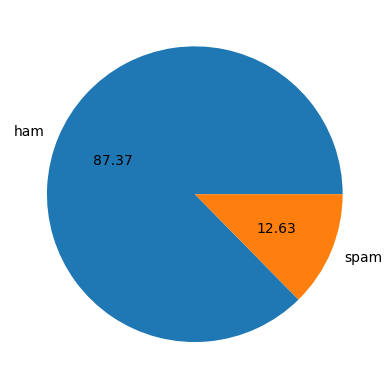

In [44]:
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")
#autopct is used to show the percentage of each class in the pie chart and %0.2f is used to format the percentage to 2 decimal places

In [45]:
#notice rhat the data is imbalanced!

In [46]:
pip install nltk


Note: you may need to restart the kernel to use updated packages.


In [47]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [48]:
import nltk
nltk.download("punkt")

[nltk_data] Downloading package punkt to /home/junix/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [49]:
#adding a new column for the number of characters in the text message
df["num_characters"] = df["text"].apply(len)
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [50]:
df["num_words"] = df["text"].apply(lambda x: len(nltk.word_tokenize(x)))
df["num_sentences"] = df["text"].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head()   

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   target          5169 non-null   int64 
 1   text            5169 non-null   object
 2   num_characters  5169 non-null   int64 
 3   num_words       5169 non-null   int64 
 4   num_sentences   5169 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 242.3+ KB


In [52]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [53]:
df[df['target'] == '1'][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


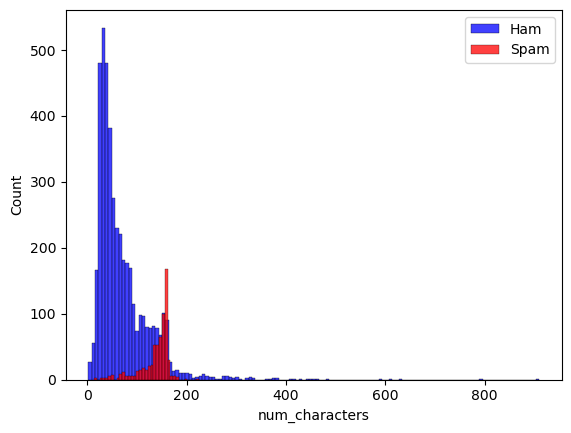

In [54]:
sns.histplot(df[df['target'] == 0]['num_characters'], color = 'blue', label='Ham')
sns.histplot(df[df['target'] == 1]['num_characters'], color = 'red', label='Spam')
plt.legend()

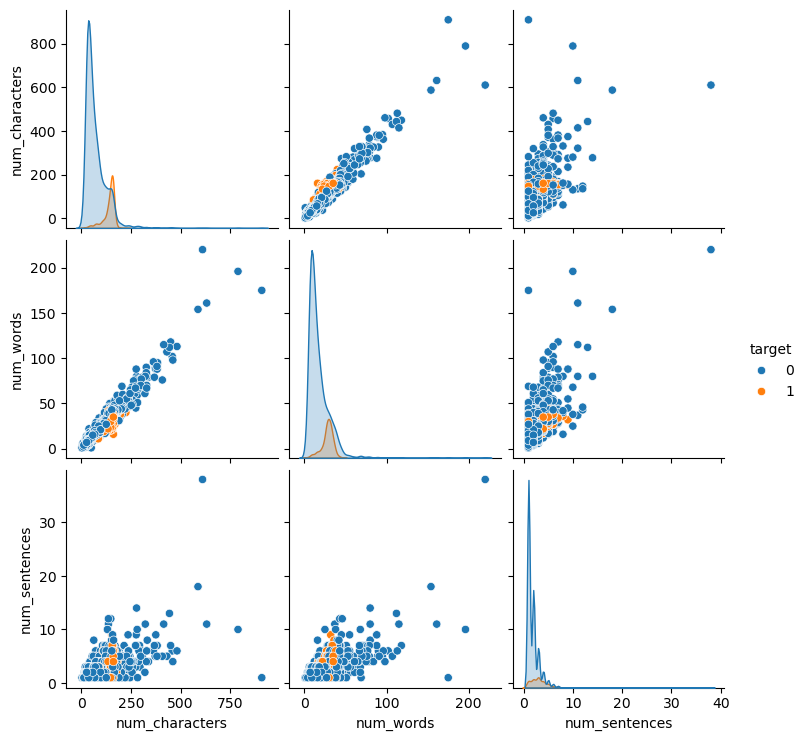

In [55]:
sns.pairplot(df, hue='target')

<Axes: >

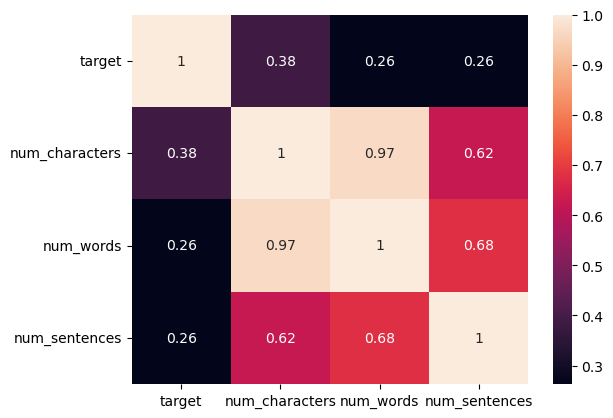

In [56]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [57]:
#text preprocessing

In [58]:
def text_preprocessing(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []
    
    for i in text:
        if i.isalnum():
            y.append(i)
            
    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)
    
    text = y[:]
    y.clear()

    for i in text:
        y.append(lemmatizer.lemmatize(i))

    return " ".join(y)

In [59]:
from nltk.corpus import stopwords
import string


In [60]:
text_preprocessing("????????????????????If you're visiting this page, you're likely here because you're")

'visiting page likely'

In [61]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [62]:
df['transformed_text'] = df['text'].apply(text_preprocessing)

In [63]:
df.sample(7)

,target,text,num_characters,num_words,num_sentences,transformed_text
796,1,"Orange customer, you may now claim your FREE C...",160,35,5,orange customer may claim free camera phone up...
5309,0,"Jolly good! By the way, will give u tickets f...",82,20,3,jolly good way give u ticket sat eve speak x
3700,0,Shall i get my pouch?,21,6,1,shall get pouch
1801,0,I wanna watch that movie,24,6,1,wan na watch movie
4305,0,Awww dat is sweet! We can think of something t...,129,32,3,awww dat sweet think something nice time tonig...
1321,0,"I wake up long ago already... Dunno, what othe...",54,13,1,wake long ago already dunno thing
1096,1,Dear Subscriber ur draw 4 å£100 gift voucher w...,142,28,3,dear subscriber ur draw 4 gift voucher b enter...


In [64]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [65]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [66]:
# spam_text = df.loc[df['target'] == 1, 'transformed_text'].fillna('').astype(str).str.cat(sep=' ')....when transformed text was a list of words instead of a string
spam_text = df.loc[df['target'] == 1, 'transformed_text'].str.cat(sep=' ')
spam_wc = wc.generate(spam_text)

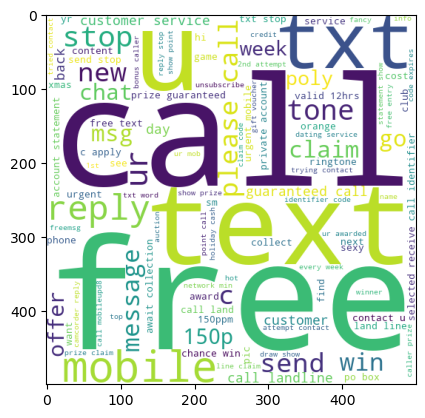

In [67]:
plt.imshow(spam_wc)

In [68]:
ham_text = df.loc[df['target'] == 0, 'transformed_text'].fillna('').astype(str).str.cat(sep=' ')
ham_wc = wc.generate(ham_text)

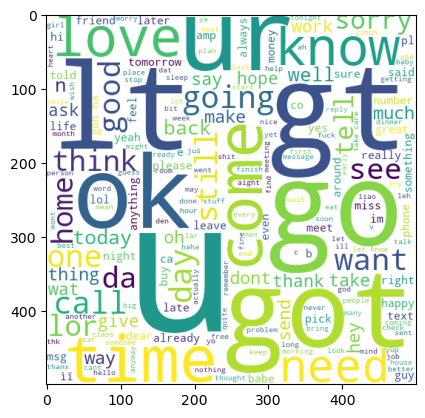

In [69]:
plt.imshow(ham_wc)

In [70]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg:
        spam_corpus.append(word)

In [71]:
len(spam_corpus)

59414

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, ' '),
  Text(1, 0, 'e'),
  Text(2, 0, 't'),
  Text(3, 0, 'a'),
  Text(4, 0, 'r'),
  Text(5, 0, 'o'),
  Text(6, 0, 'n'),
  Text(7, 0, 'l'),
  Text(8, 0, 'i'),
  Text(9, 0, 'c'),
  Text(10, 0, 's'),
  Text(11, 0, '0'),
  Text(12, 0, 'p'),
  Text(13, 0, 'd'),
  Text(14, 0, 'm'),
  Text(15, 0, 'u'),
  Text(16, 0, 'g'),
  Text(17, 0, 'y'),
  Text(18, 0, '2'),
  Text(19, 0, 'h'),
  Text(20, 0, '1'),
  Text(21, 0, '8'),
  Text(22, 0, 'w'),
  Text(23, 0, 'b'),
  Text(24, 0, 'x'),
  Text(25, 0, 'f'),
  Text(26, 0, 'k'),
  Text(27, 0, '5'),
  Text(28, 0, '7'),
  Text(29, 0, 'v')])

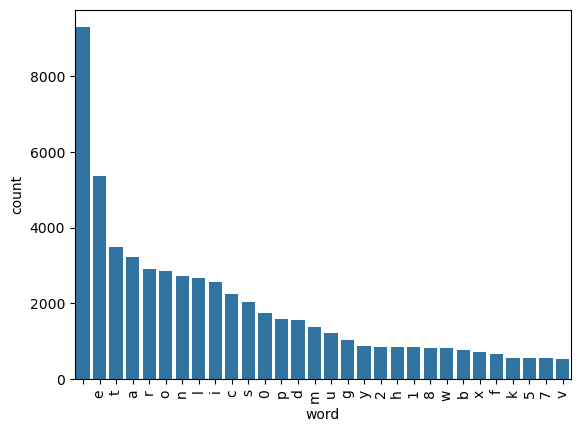

In [72]:
from collections import Counter
counter_df = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])
sns.barplot(data=counter_df, x='word', y='count')
plt.xticks(rotation='vertical')

In [73]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg:
        ham_corpus.append(word)

In [74]:
len(ham_corpus)

189501

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, ' '),
  Text(1, 0, 'e'),
  Text(2, 0, 'a'),
  Text(3, 0, 't'),
  Text(4, 0, 'o'),
  Text(5, 0, 'n'),
  Text(6, 0, 'i'),
  Text(7, 0, 'l'),
  Text(8, 0, 'r'),
  Text(9, 0, 's'),
  Text(10, 0, 'g'),
  Text(11, 0, 'd'),
  Text(12, 0, 'h'),
  Text(13, 0, 'u'),
  Text(14, 0, 'm'),
  Text(15, 0, 'c'),
  Text(16, 0, 'y'),
  Text(17, 0, 'p'),
  Text(18, 0, 'k'),
  Text(19, 0, 'w'),
  Text(20, 0, 'b'),
  Text(21, 0, 'f'),
  Text(22, 0, 'v'),
  Text(23, 0, 'x'),
  Text(24, 0, 'j'),
  Text(25, 0, '2'),
  Text(26, 0, 'z'),
  Text(27, 0, '4'),
  Text(28, 0, 'q'),
  Text(29, 0, '1')])

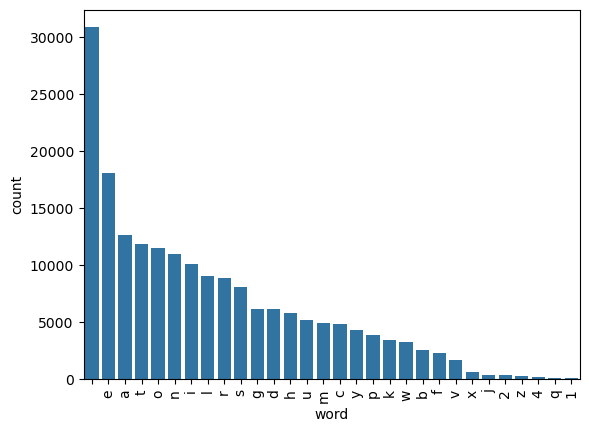

In [75]:
from collections import Counter
counter_df = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])
sns.barplot(data=counter_df, x='word', y='count')
plt.xticks(rotation='vertical')

In [76]:
#Model Building

In [77]:
#1. Naive Bayes

In [78]:
from sklearn.feature_extraction.text import CountVectorizer #Bag of Words 
cv = CountVectorizer()
from sklearn.feature_extraction.text import TfidfVectorizer #TF-IDF
tfidf = TfidfVectorizer(max_features = 3000)

In [79]:
X = cv.fit_transform(df['transformed_text']).toarray()
X1 = tfidf.fit_transform(df['transformed_text']).toarray()

In [80]:
print(X)
print(X1)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [81]:
X.shape

(5169, 7493)

In [82]:
y = df['target'].values

In [83]:
from sklearn.model_selection import train_test_split

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y, test_size=0.2, random_state=2)

In [85]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score

In [86]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [233]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
# print(classification_report(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.8945841392649904
[[807  89]
 [ 20 118]]
0.5700483091787439


In [234]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.9632495164410058
[[870  26]
 [ 12 126]]
0.8289473684210527


In [235]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.9690522243713733
[[893   3]
 [ 29 109]]
0.9732142857142857


In [236]:
bnb.fit(X_train1, y_train1)
y_pred31 = bnb.predict(X_test1)
print(accuracy_score(y_test1, y_pred31))
print(confusion_matrix(y_test1, y_pred31))
print(precision_score(y_test1, y_pred31))

0.9690522243713733
[[893   3]
 [ 29 109]]
0.9732142857142857


In [237]:
gnb.fit(X_train1, y_train1)
y_pred11 = gnb.predict(X_test1)
print(accuracy_score(y_test1, y_pred11))
print(confusion_matrix(y_test1, y_pred11))
print(precision_score(y_test1, y_pred11))

0.8887814313346228
[[807  89]
 [ 26 112]]
0.5572139303482587


In [238]:
mnb.fit(X_train1, y_train1)
y_pred21 = mnb.predict(X_test1)
print(accuracy_score(y_test1, y_pred21))
print(confusion_matrix(y_test1, y_pred21))
print(precision_score(y_test1, y_pred21))

0.9535783365570599
[[896   0]
 [ 48  90]]
1.0


In [239]:
#we use tfidf vectorizer for the model building because it gives better results than the bag of words model.with multinomial naive bayes algorithm.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB

In [9]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver = "liblinear", penalty = "l1")
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
gdbt = GradientBoostingClassifier(n_estimators=50, random_state=2)
mnb = MultinomialNB()

In [10]:
clfs = {
    "SVC": svc,
    "KN": knc,
    "DTC": dtc,
    "LRC": lrc,
    "RFC": rfc,
    "xgb": xgb,
    "ABC": abc,
    "ETC": etc,
    "BC": bc,
    "GDBT": gdbt,
    "MNB": mnb
}

In [263]:
def train_classifier(clf, X_train1, y_train1, X_test1, y_test1):
    clf.fit(X_train1, y_train1)
    y_pred = clf.predict(X_test1)
    accuracy = accuracy_score(y_test1, y_pred)
    precision = precision_score(y_test1, y_pred)
    return accuracy, precision

In [264]:
train_classifier(svc, X_train1, y_train1, X_test1, y_test1)

(0.97678916827853, 0.975)

In [265]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train1, y_train1, X_test1, y_test1)
    print("For ", name)
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

    # accuracy_scores.append(current_accuracy)
    # precision_scores.append(current_precision)

For  SVC
For  KN
For  DTC
For  LRC
For  RFC
For  xgb
For  ABC
For  ETC
For  BC
For  GDBT
For  MNB


In [246]:
print(len(clfs))
print(len(accuracy_scores))
print(len(precision_scores))

11
11
11


In [247]:
algorithm_names = list(clfs.keys())
performance_df = pd.DataFrame({
    "Algorithm": algorithm_names,
    "Accuracy": accuracy_scores,
    "Precision": precision_scores
}).sort_values(by="Precision", ascending=False)

In [248]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.897485,1.000000
10,MNB,0.953578,1.000000
7,ETC,0.974855,0.982759
4,RFC,0.971954,0.982301
0,SVC,0.973888,0.974359
5,xgb,0.974855,0.951613
3,LRC,0.942940,0.907216
9,GDBT,0.947776,0.875000
8,BC,0.962282,0.872180
6,ABC,0.926499,0.860465


In [249]:
performance_df1 = pd.melt(performance_df, id_vars="Algorithm")

In [254]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.897485
1,MNB,Accuracy,0.953578
2,ETC,Accuracy,0.974855
3,RFC,Accuracy,0.971954
4,SVC,Accuracy,0.973888
5,xgb,Accuracy,0.974855
6,LRC,Accuracy,0.942940
7,GDBT,Accuracy,0.947776
8,BC,Accuracy,0.962282
9,ABC,Accuracy,0.926499


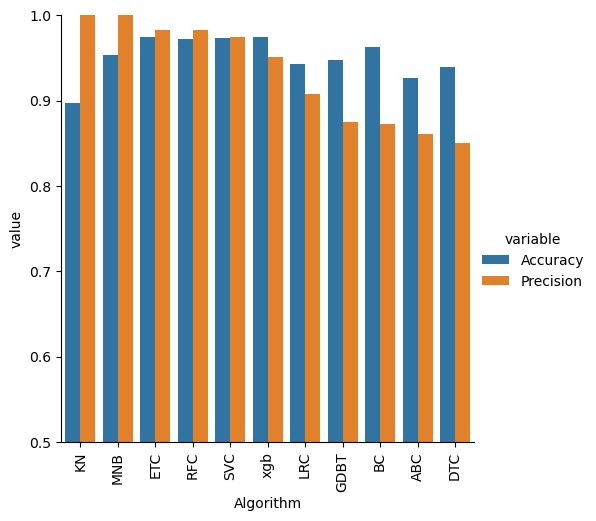

In [250]:
sns.catplot(x="Algorithm", y="value", hue="variable", data=performance_df1, kind="bar")
plt.xticks(rotation=90)
plt.ylim(0.5, 1.0)
plt.show()

In [251]:
#improving thr model by tuning the hyperparameters of the best performing model which is multinomial naive bayes in this case. we can use grid search cv to find the best hyperparameters for the model.

In [266]:
# temp_df = pd.DataFrame({
#     "Algorithm": clfs.keys(),
#     'Accuracy_max_ft_3000': accuracy_scores,
#     'Precision_max_ft_3000': precision_scores
# })

temp_df = pd.DataFrame({
    'Algorithm':clfs.keys(),
    'Accuracy_max_ft_3000':accuracy_scores,
    'Precision_max_ft_3000':precision_scores
}).sort_values('Precision_max_ft_3000',ascending=False)

In [267]:
temp_df

,Algorithm,Accuracy_max_ft_3000,Precision_max_ft_3000
1,KN,0.906190,1.000000
10,MNB,0.973888,1.000000
7,ETC,0.979691,0.983471
4,RFC,0.974855,0.982759
0,SVC,0.976789,0.975000
5,xgb,0.968085,0.956522
3,LRC,0.950677,0.939394
9,GDBT,0.947776,0.888889
6,ABC,0.923598,0.873418
8,BC,0.957447,0.867188


In [268]:
performance_df.merge(temp_df, on="Algorithm")

,Algorithm,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000
0,KN,0.897485,1.000000,0.906190,1.000000
1,MNB,0.953578,1.000000,0.973888,1.000000
2,ETC,0.974855,0.982759,0.979691,0.983471
3,RFC,0.971954,0.982301,0.974855,0.982759
4,SVC,0.973888,0.974359,0.976789,0.975000
5,xgb,0.974855,0.951613,0.968085,0.956522
6,LRC,0.942940,0.907216,0.950677,0.939394
7,GDBT,0.947776,0.875000,0.947776,0.888889
8,BC,0.962282,0.872180,0.957447,0.867188
9,ABC,0.926499,0.860465,0.923598,0.873418


In [269]:
#votingclassifier

In [12]:
svc = SVC(kernel='sigmoid', gamma=1.0, probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [13]:
voting = VotingClassifier(estimators=[('svm', svc), ('mnb', mnb), ('etc', etc)], voting='soft')

In [87]:
voting.fit(X_train1, y_train1)

,estimators,"[('svm', ...), ('mnb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,1.0
,coef0,0.0


In [88]:
y_pred = voting.predict(X_test1)
print("accuracy:", accuracy_score(y_test1, y_pred))
print("precision:", precision_score(y_test1, y_pred))   

accuracy: 0.9806576402321083
precision: 0.9836065573770492
